**Brain Tumor Detection Using a Convolutional Neural Network**

The dataset contains 2 folders: yes and no which contains 253 Brain MRI Images
The folder yes contains 155 Brain MRI Images that are tumorous and the folder no contains 98 Brain MRI Images that are non-tumorous.

In [1]:
## Import all the necessary modules

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import matplotlib.pyplot as plt
import itertools

from sklearn.metrics import confusion_matrix,classification_report
from sklearn.model_selection import train_test_split
from PIL import Image

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import cv2

In [ ]:
### uplaod the file (Using Google Colab for this !!!)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving BTC.zip to BTC (2).zip


In [ ]:
import zipfile
with zipfile.ZipFile("BTC.zip",'r') as zip_ref:
  zip_ref.extractall("BTC")

In [ ]:
print(os.listdir("BTC"))

['brain_tumor_dataset']


In [ ]:
data_dir = 'BTC/brain_tumor_dataset'

In [ ]:
## Brain tumor sample dataset images  with 2 classes - YES and NO

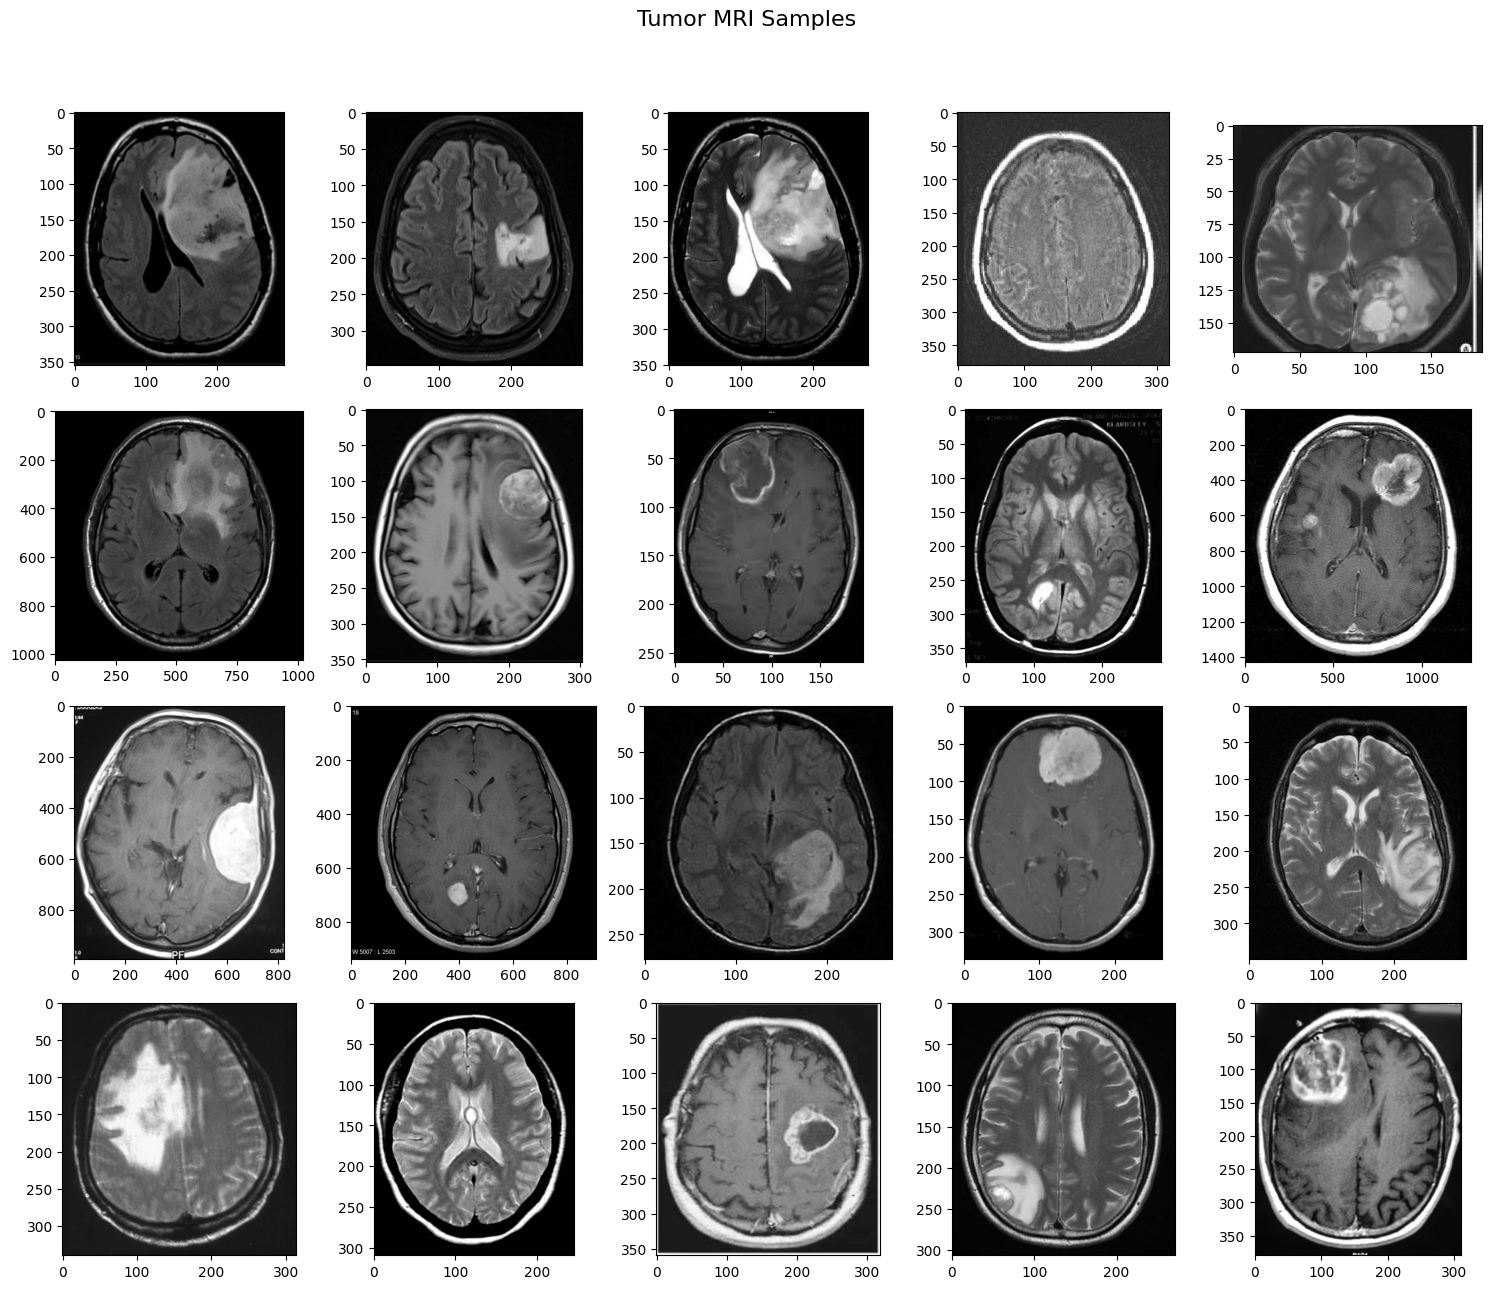

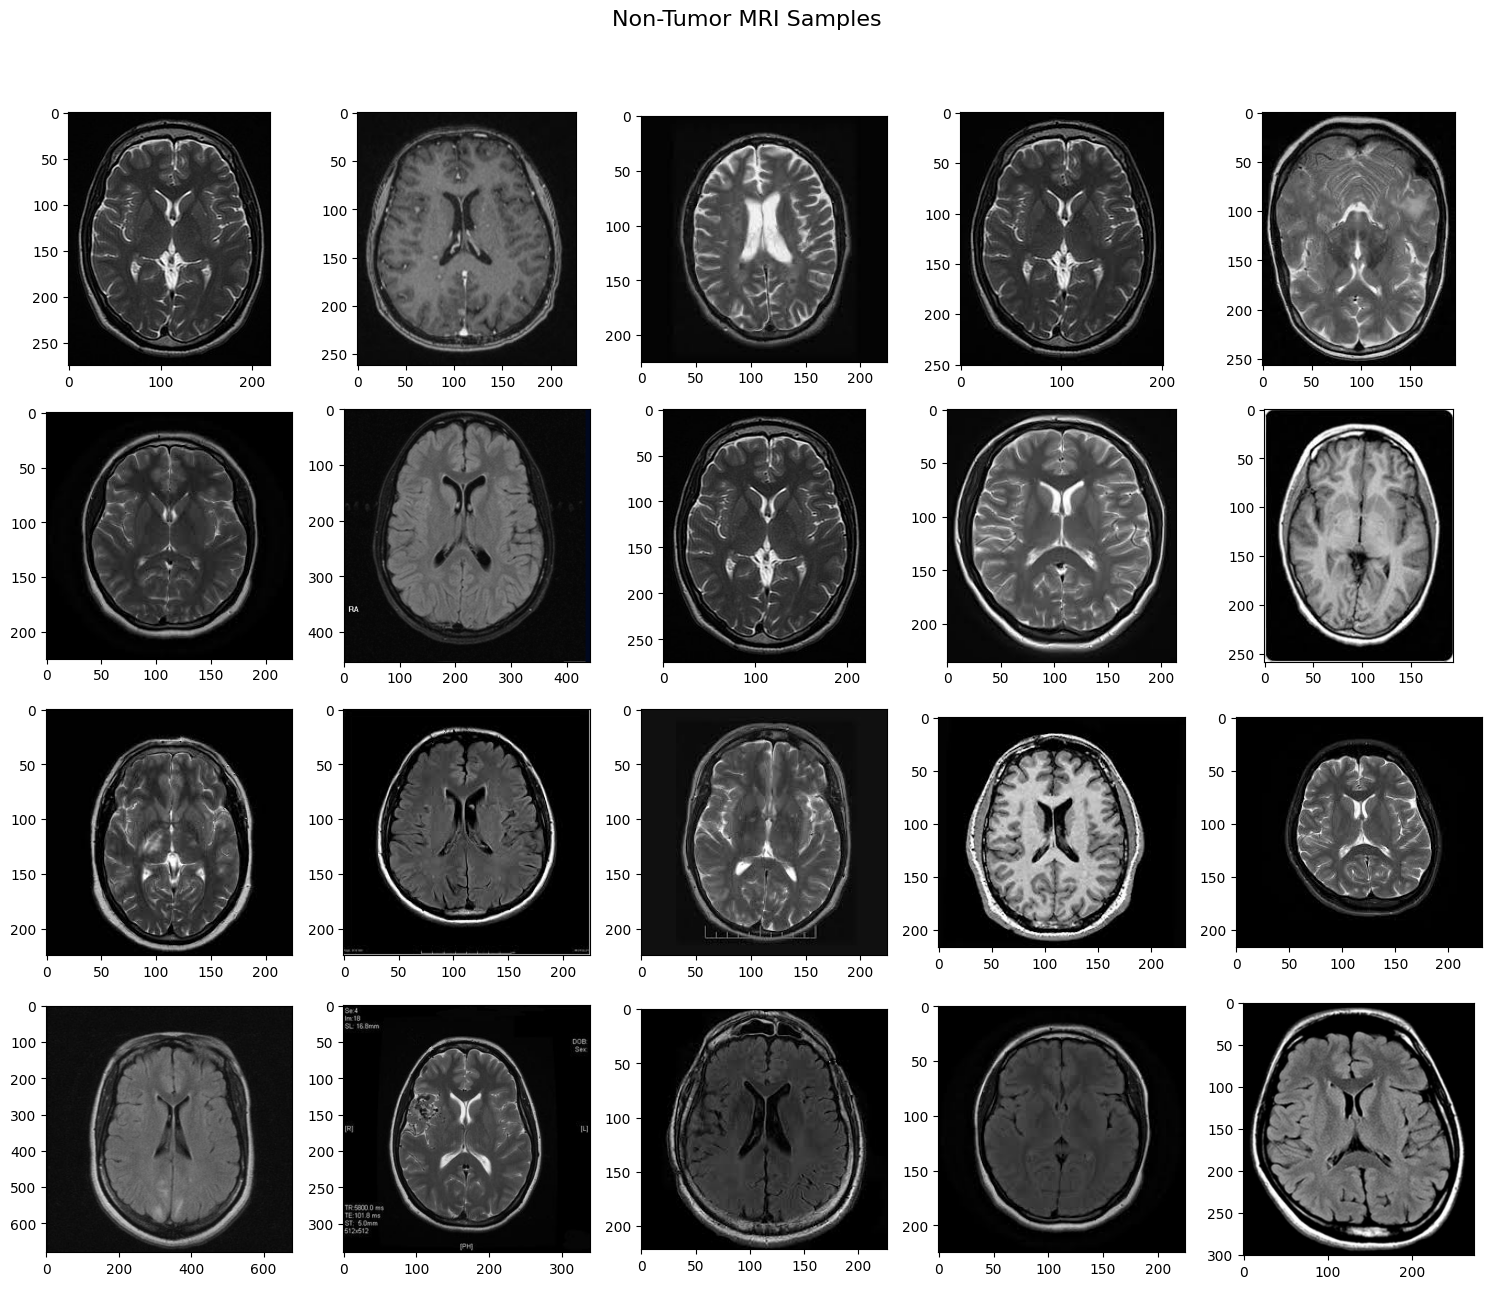

In [ ]:
yes_dir = 'BTC/brain_tumor_dataset/yes'
no_dir = 'BTC/brain_tumor_dataset/no'

yes_img = os.listdir(yes_dir)[:20]
no_img = os.listdir(no_dir)[:20]

plt.figure(figsize=(15, 24))
plt.suptitle("Tumor MRI Samples", fontsize=16, y=1.02)

for i, img_name in enumerate(yes_img):
  img_path = os.path.join(yes_dir,img_name)
  img = cv2.imread(img_path)
  img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
  plt.subplot(8,5,i+1)
  plt.imshow(img)

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 24))
plt.suptitle("Non-Tumor MRI Samples", fontsize=16, y=1.02)

for i,img_name in enumerate(no_img):
  img_path = os.path.join(no_dir,img_name)
  img = cv2.imread(img_path)
  img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
  plt.subplot(8,5,i+1)
  plt.imshow(img)

plt.tight_layout()
plt.show()

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [ ]:
train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


In [ ]:
### Building the Convolutional Neural Netwrok model

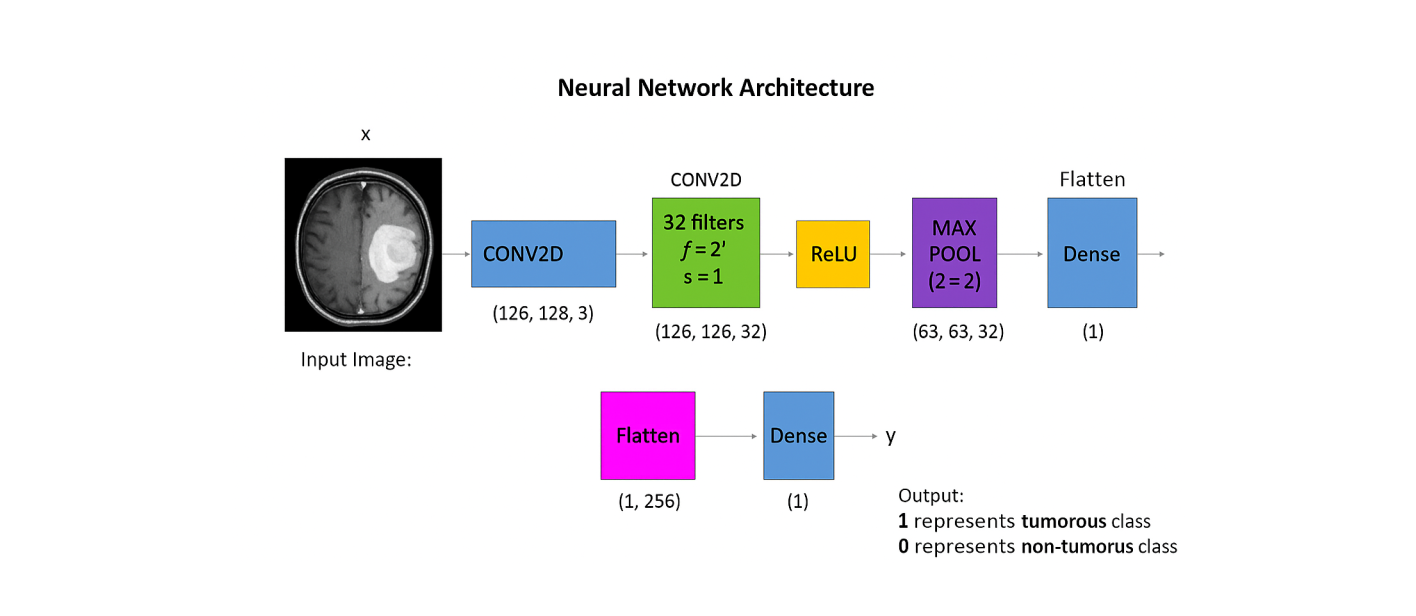

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # For binary classification
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,699,009 (6.48 MB)

 Trainable params: 1,699,009 (6.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 467ms/step - accuracy: 0.6023 - loss: 0.6695 - val_accuracy: 0.7600 - val_loss: 0.5505
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.8009 - loss: 0.5006 - val_accuracy: 0.7400 - val_loss: 0.5506
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.8117 - loss: 0.4610 - val_accuracy: 0.7600 - val_loss: 0.5420
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.8303 - loss: 0.3806 - val_accuracy: 0.7800 - val_loss: 0.5278
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.8845 - loss: 0.3765 - val_accuracy: 0.8000 - val_loss: 0.5060
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.8290 - loss: 0.3742 - val_accuracy: 0.8000 - val_loss: 0.6065
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.8591 - loss: 0.3049 - val_accuracy: 0.8000 - val_loss: 0.4561
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.9200 - loss: 0.1954 - val_accuracy: 0.8400 - val_loss: 0.5266

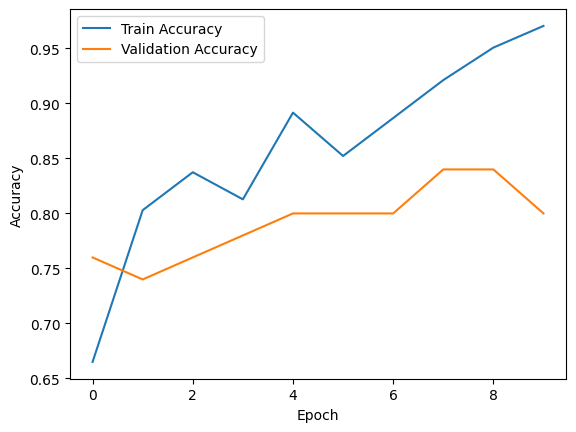

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [ ]:
from tensorflow.keras.preprocessing import image

# Upload an image
from google.colab import files
uploaded = files.upload()

for filename in uploaded.keys():
    img_path = filename

    # Load and preprocess
    img = image.load_img(img_path, target_size=(128, 128))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array / 255.0, axis=0)

    # Predict
    prediction = model.predict(img_array)[0][0]

    # Output result
    label = "Tumor" if prediction > 0.5 else "No Tumor"
    confidence = prediction if prediction > 0.5 else 1 - prediction

    # Display
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction: {label} ({confidence*100:.2f}%)")
    plt.show()


In [ ]:
## Observation: The model predicts well to detect tumor or non tumor data